In [1]:
! pip install kaggle
! pip install onnx
! pip install dagshub
! pip install mlflow
from google.colab import drive
drive.mount('/content/drive')
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json
# ! kaggle competitions download -c walmart-recruiting-store-sales-forecasting
# ! unzip walmart-recruiting-store-sales-forecasting

Mounted at /content/drive


In [2]:
# ! unzip test.csv.zip
# ! unzip train.csv.zip
# ! unzip sampleSubmission.csv.zip
# ! unzip features.csv.zip

In [3]:
# ! rm -rf test.csv.zip
# ! rm -rf train.csv.zip
# ! rm -rf sampleSubmission.csv.zip
# ! rm -rf features.csv.zip

In [4]:
# 1. Clone your GitHub repo
!git clone https://github.com/arazm21/ML-final_project

# 2. Add the cloned repo (or specific folder) to sys.path
import sys
sys.path.insert(0, '/content/ML-final_project')


Cloning into 'ML-final_project'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 24 (delta 0), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 3.72 MiB | 10.99 MiB/s, done.


In [1]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


In [2]:
# features_df = pd.read_csv('ML-final_project/data/features.csv/features.csv')
# sample_submission_df = pd.read_csv('ML-final_project/data/sampleSubmission.csv/sampleSubmission.csv')
# test_df = pd.read_csv('ML-final_project/data/test.csv/test.csv')
# train_df = pd.read_csv('ML-final_project/data/train.csv/train.csv')
# stores_df = pd.read_csv('ML-final_project/data/stores.csv')

features_df = pd.read_csv('data/features.csv/features.csv')
sample_submission_df = pd.read_csv('data/sampleSubmission.csv/sampleSubmission.csv')
test_df = pd.read_csv('data/test.csv/test.csv')
train_df = pd.read_csv('data/train.csv/train.csv')
stores_df = pd.read_csv('data/stores.csv')

In [5]:
display(train_df.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
import pandas as pd

# Use the actual date range present in the data
all_dates = sorted(train_df['Date'].unique())

# Collect filled groups
filled_groups = []

# Process each Store/Dept group
for (store, dept), group in train_df.groupby(['Store', 'Dept']):
    group = group.set_index('Date')

    # Reindex to actual full dates in data
    reindexed = group.reindex(all_dates)
    reindexed.index.name = 'Date'

    # Fill identifying columns
    reindexed['Store'] = store
    reindexed['Dept'] = dept

    # Fill missing sales with 0
    reindexed['Weekly_Sales'] = reindexed['Weekly_Sales'].fillna(0)

    filled_groups.append(reindexed.reset_index())

# Concatenate full DataFrame
train_df_filled = pd.concat(filled_groups).sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
train_df_filled["Weekly_Sales"] = train_df_filled["Weekly_Sales"]/1000.0


In [5]:
train_df_filled.to_csv('temp/train_df_filled.csv', index=False)

In [6]:
train_df_filled = train_df_filled.drop(columns=['IsHoliday'], errors='ignore')

# Merge on 'Store' and 'Date'
train_merged = pd.merge(train_df_filled, features_df, on=['Store', 'Date'], how='left')
test_merged = pd.merge(test_df, features_df, on=['Store', 'Date'], how='left')
train_merged = pd.merge(train_merged, stores_df, on='Store', how='left')
test_merged = pd.merge(test_merged, stores_df, on='Store', how='left')

In [7]:
print(train_merged.dtypes)
display(train_merged.head())


Index(['Date', 'Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday', 'Type', 'Size'],
      dtype='object')
Date             object
Store             int64
Dept              int64
Weekly_Sales    float64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Type             object
Size              int64
dtype: object


,Date,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,2010-02-05,1,1,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,2010-02-12,1,1,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,2010-02-19,1,1,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,2010-02-26,1,1,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,2010-03-05,1,1,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## helper functions

### 1.feature engineering functions

In [8]:
def add_holiday_lookahead(df):
    """
    Adds:
    - IsHolidayNextWeek: True if this week OR next week is a holiday.
    - IsHolidayIn2Weeks: True if this week OR next 2 weeks are holidays.
    """
    df = df.sort_values(by=['Store', 'Date']).copy()

    # current and future IsHoliday flags
    curr = df['IsHoliday'].astype(bool)
    next_1 = df.groupby('Store')['IsHoliday'].shift(-1).fillna(False).astype(bool)
    next_2 = df.groupby('Store')['IsHoliday'].shift(-2).fillna(False).astype(bool)

    df['IsHolidayNextWeek'] = (curr | next_1).astype(int)
    df['IsHolidayIn2Weeks'] = (curr | next_1 | next_2).astype(int)

    return df

def add_date_features(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    # df['Day'] = df['Date'].dt.day
    # df['DayOfWeek'] = df['Date'].dt.weekday  # Monday=0, Sunday=6
    return df

# use this method for model which are not sequencial, i.e.xgboost
def drop_unneeded_columns(df, drop_date=True):
    """
    Drop or convert fields not usable by XGBoost directly.
    """
    df = df.copy()
    if drop_date and 'Date' in df.columns:
        df = df.drop(columns=['Date'])
    return df


## connecting wandb and dagshub

In [17]:
project_name = 'ML-final_project'
run_name = "test_run_1"
repo_owner = "arazm21"

In [18]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arazm21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
import dagshub
import mlflow
import mlflow.sklearn
dagshub.init(repo_owner=repo_owner, repo_name=project_name, mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cd25537e-680f-44a0-9c17-2795377d273b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=6081d3ccba1aaba46d9c80c9162f53fae7ff11afa8bf92adafb899c73f4b1b7a




Output()

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-final_project"

Repository arazm21/ML-final_project initialized!

In [ ]:
# with wandb.init(project=project_name,
#                 config=hyperparameters,
#                 name = run_name):


## getting data ready

## plots

### checking 3 departament/store combinations

143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00


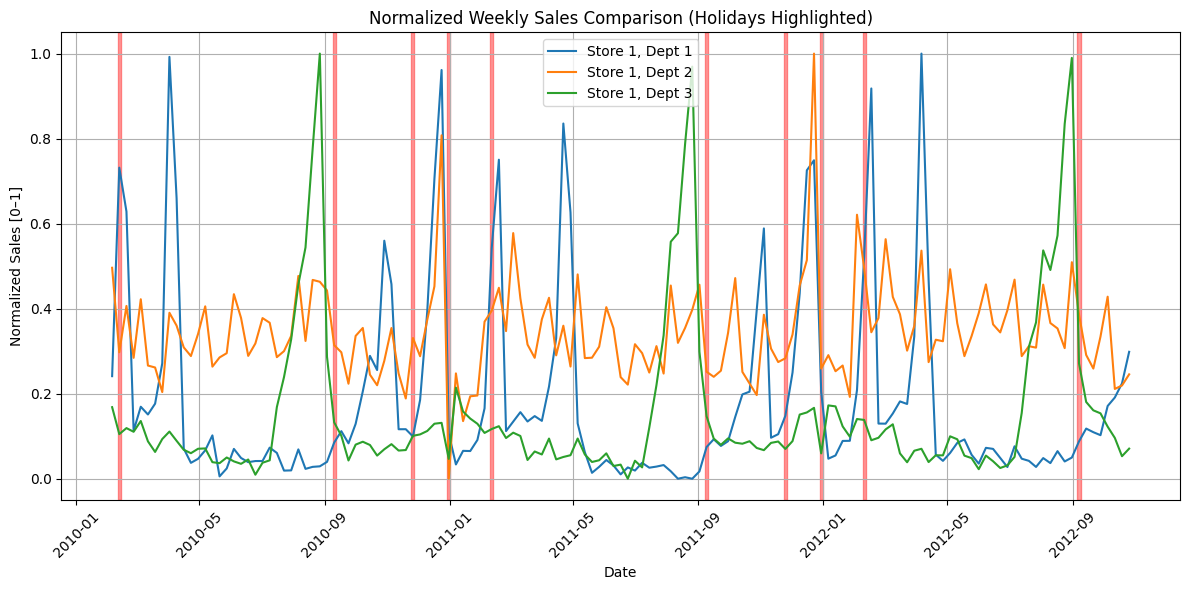

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
train_merged = train_merged.sort_values(['Store', 'Dept', 'Date'])

groups = [g for _, g in train_df.groupby(['Store', 'Dept']) if len(g) > 100]
selected = groups[:3]

selected_series = []
for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    if len(group) >= 100:
        selected_series.append((store, dept))
        if len(selected_series) == 3:
            break

# Plot normalized series
plt.figure(figsize=(12, 6))
ax = plt.gca()

for i, (store, dept) in enumerate(selected_series):
    series = train_merged[(train_merged['Store'] == store) & 
                          (train_merged['Dept'] == dept)].sort_values('Date').copy()

    series['Date'] = pd.to_datetime(series['Date'])  # 🛠️ Ensure datetime
    print(len(series), series["Date"].iloc[0], series["Date"].iloc[-1])

    # Min-Max normalization
    normalized_sales = (series['Weekly_Sales'] - series['Weekly_Sales'].min()) / \
                       (series['Weekly_Sales'].max() - series['Weekly_Sales'].min())
    
    plt.plot(series['Date'], normalized_sales, label=f"Store {store}, Dept {dept}")

    # Highlight holiday weeks
    holidays = series[series['IsHoliday'] == True]['Date']
    for holiday_date in holidays:
        ax.axvspan(holiday_date - pd.Timedelta(days=1.5),
                   holiday_date + pd.Timedelta(days=1.5),
                   color='red', alpha=0.15)

plt.title('Normalized Weekly Sales Comparison (Holidays Highlighted)')
plt.xlabel('Date')
plt.ylabel('Normalized Sales [0–1]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
# Expected sales range differences:
print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))

                 mean        std
Store Dept                      
1     1     22.513323   9.854349
      2     46.102090   3.440673
      3     13.150478   8.708979
      4     36.964154   2.930698
      5     24.257941  11.330286
...               ...        ...
45    94     3.458017   2.005570
      95    52.896167   5.117962
      96     0.000042   0.000350
      97     6.466962   0.659740
      98     0.529841   0.383198

[3331 rows x 2 columns]


C:\Users\alex\AppData\Local\Temp\ipykernel_19088\3343407106.py:2: FutureWarning: The provided callable <function mean at 0x0000018B6665AF20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))
C:\Users\alex\AppData\Local\Temp\ipykernel_19088\3343407106.py:2: FutureWarning: The provided callable <function std at 0x0000018B6665B060> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))


### trends across all stores/departaments

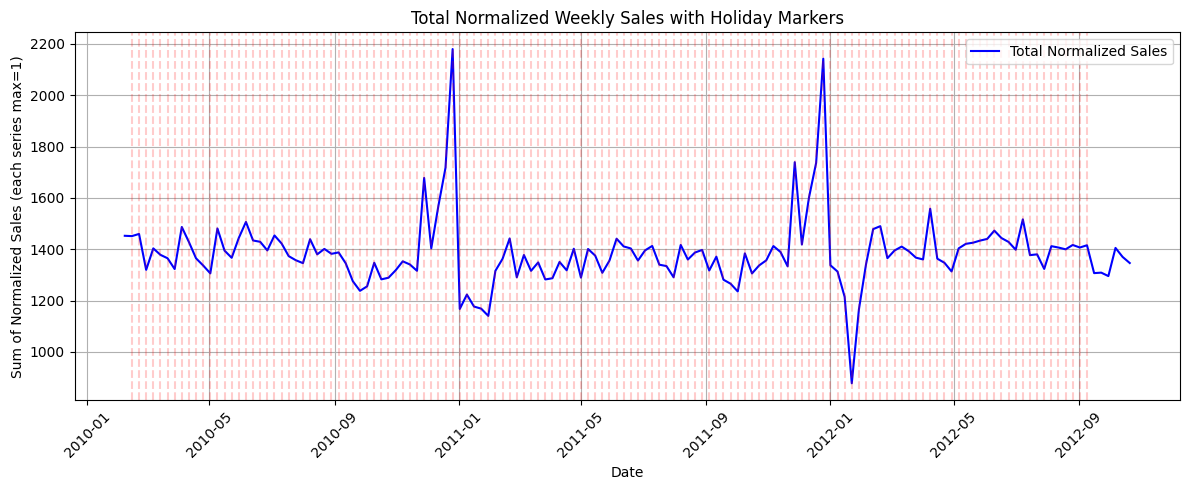

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is datetime
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# Define common weekly index
common_index = pd.date_range(start=train_merged['Date'].min(),
                             end=train_merged['Date'].max(),
                             freq='W')

# Step 1: Normalize each Store–Dept combo (max = 1)
normalized_series_list = []

for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(common_index).interpolate(limit_direction='both')
    normalized_series_list.append(normalized)

# Step 2: Add all normalized series together
normalized_df = pd.DataFrame(normalized_series_list).T
total_normalized_sales = normalized_df.sum(axis=1)

# Step 3: Get unique holiday weeks (from any store/dept)
holiday_weeks = (
    train_merged[train_merged['IsHoliday'] == True]
    .set_index('Date')
    .resample('W').max()
    .index
)

# Step 4: Plot with holiday lines
plt.figure(figsize=(12, 5))
plt.plot(common_index, total_normalized_sales, color='blue', label='Total Normalized Sales')

# Draw vertical lines for holidays
for date in holiday_weeks:
    plt.axvline(date, color='red', linestyle='--', alpha=0.2)

plt.title('Total Normalized Weekly Sales with Holiday Markers')
plt.xlabel('Date')
plt.ylabel('Sum of Normalized Sales (each series max=1)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### each store agains each other (summing departaments)

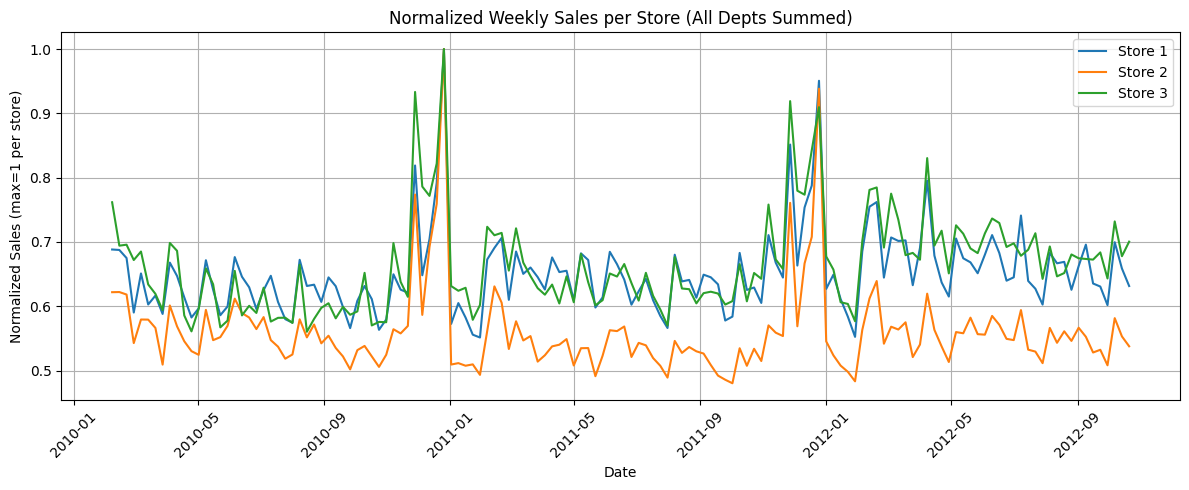

In [10]:
import matplotlib.pyplot as plt

# Set weekly index range
weekly_index = pd.date_range(train_merged['Date'].min(), train_merged['Date'].max(), freq='W')

# Step 1: Group by Store (sum over Depts)
store_series_list = []
store_ids = []

for store, group in train_merged.groupby('Store'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    store_series_list.append(normalized)
    store_ids.append(store)

    if len(store_series_list) == 3:
        break

# Plot 3 stores
plt.figure(figsize=(12, 5))
for series, store_id in zip(store_series_list, store_ids):
    plt.plot(weekly_index, series, label=f"Store {store_id}")

plt.title("Normalized Weekly Sales per Store (All Depts Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per store)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### each departament agains each other (summing all stores)

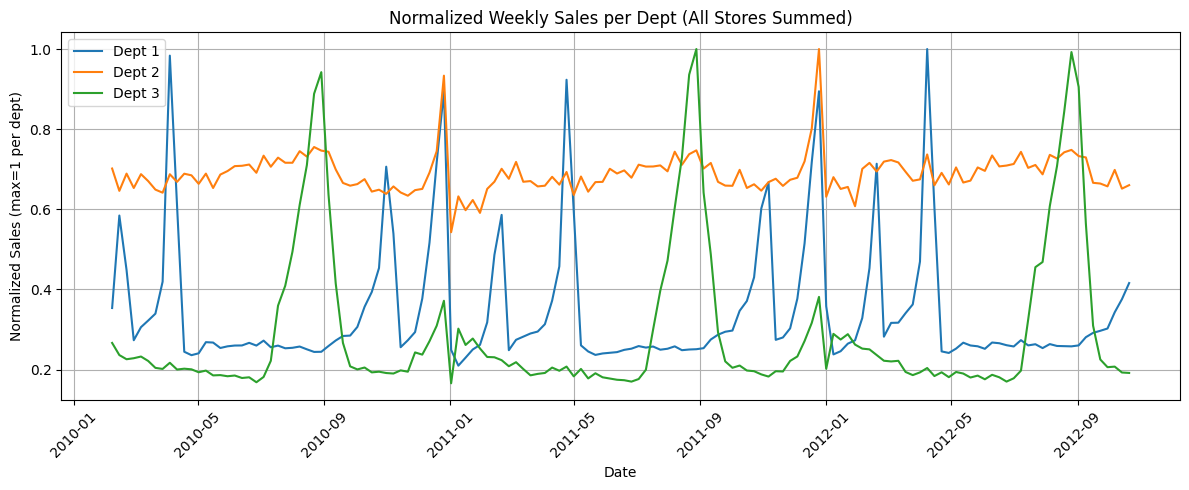

In [11]:
# Step 2: Group by Dept (sum over Stores)
dept_series_list = []
dept_ids = []

for dept, group in train_merged.groupby('Dept'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    dept_series_list.append(normalized)
    dept_ids.append(dept)

    if len(dept_series_list) == 3:
        break

# Plot 3 depts
plt.figure(figsize=(12, 5))
for series, dept_id in zip(dept_series_list, dept_ids):
    plt.plot(weekly_index, series, label=f"Dept {dept_id}")

plt.title("Normalized Weekly Sales per Dept (All Stores Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per dept)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## train!!!

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import plotly.express as px


In [13]:
import plotly.express as px
import pandas as pd

def plot_sales(df: pd.DataFrame, store: int, dep: int) -> None:
    """
    Plots weekly sales for a specific store and department.
    
    Parameters:
    - df: Full dataset (like train_merged)
    - store: Store number (int)
    - dep: Department number (int)
    """
    # Ensure datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Filter for Store and Dept
    combo_df = df[(df['Store'] == store) & (df['Dept'] == dep)].copy()

    if combo_df.empty:
        print(f"No data for Store {store}, Dept {dep}")
        return

    # Aggregate by Date
    combo_df = combo_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
    combo_df.rename(columns={'Weekly_Sales': 'Sales', 'Date': 'Month'}, inplace=True)

    # Plot
    fig = px.line(combo_df, x='Month', y='Sales', labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18),
                      title_text=f'Store {store}, Dept {dep} Weekly Sales',
                      width=650, title_x=0.5, height=400)

    return fig.show()


In [14]:
plot_sales(train_merged, store=1, dep=1)


In [15]:
from scipy.stats import boxcox
import pandas as pd
import plotly.express as px

# Ensure datetime
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# Make a copy to avoid overwriting original
train_boxcox = train_merged.copy()

# New column to store Box-Cox transformed sales
train_boxcox['Sales_Boxcox'] = np.nan

# Dictionary to store lambda for each group (for inverse later)
boxcox_lambdas = {}

# Apply Box-Cox per (Store, Dept)
for (store, dept), group in train_boxcox.groupby(['Store', 'Dept']):
    sales = group['Weekly_Sales'].clip(lower=1)  # avoid 0 or negative
    try:
        transformed, lam = boxcox(sales)
        train_boxcox.loc[group.index, 'Sales_Boxcox'] = transformed
        boxcox_lambdas[(store, dept)] = lam
    except Exception as e:
        print(f"Skipping Store {store}, Dept {dept} due to Box-Cox error: {e}")


Skipping Store 1, Dept 45 due to Box-Cox error: Data must not be constant.
Skipping Store 1, Dept 47 due to Box-Cox error: Data must not be constant.
Skipping Store 1, Dept 51 due to Box-Cox error: Data must not be constant.
Skipping Store 1, Dept 54 due to Box-Cox error: Data must not be constant.
Skipping Store 1, Dept 78 due to Box-Cox error: Data must not be constant.
Skipping Store 2, Dept 39 due to Box-Cox error: Data must not be constant.
Skipping Store 2, Dept 45 due to Box-Cox error: Data must not be constant.
Skipping Store 2, Dept 51 due to Box-Cox error: Data must not be constant.
Skipping Store 2, Dept 54 due to Box-Cox error: Data must not be constant.
Skipping Store 2, Dept 60 due to Box-Cox error: Data must not be constant.
Skipping Store 2, Dept 78 due to Box-Cox error: Data must not be constant.
Skipping Store 3, Dept 28 due to Box-Cox error: Data must not be constant.
Skipping Store 3, Dept 45 due to Box-Cox error: Data must not be constant.
Skipping Store 3, Dept 47

In [61]:
display(train_boxcox[(train_boxcox['Store'] == 1) & (train_boxcox['Dept'] == 2)])

,Date,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,Sales_Boxcox
143,2010-02-05,1,2,50605.27,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,0.472786
144,2010-02-12,1,2,44682.74,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,0.472786
145,2010-02-19,1,2,47928.89,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,0.472786
146,2010-02-26,1,2,44292.87,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,0.472786
147,2010-03-05,1,2,48397.98,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,0.472786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,2012-09-28,1,2,45784.76,76.08,3.666,3666.27,7.64,1.65,1417.96,4744.28,222.981658,6.908,False,A,151315,0.472786
282,2012-10-05,1,2,48577.08,68.55,3.617,8077.89,NaN,18.22,3617.43,3626.14,223.181477,6.573,False,A,151315,0.472786
283,2012-10-12,1,2,42112.67,62.99,3.601,2086.18,NaN,8.11,602.36,5926.45,223.381296,6.573,False,A,151315,0.472786
284,2012-10-19,1,2,42354.72,67.97,3.594,950.33,NaN,4.93,80.25,2312.85,223.425723,6.573,False,A,151315,0.472786


In [16]:
# Example: Plot original vs. transformed for (Store 1, Dept 1)
sample = train_boxcox[(train_boxcox['Store'] == 1) & (train_boxcox['Dept'] == 2)].copy()

fig = px.line(sample, x='Date', y='Weekly_Sales', title='Original Sales - Store 1, Dept 1')
fig.show()

fig = px.line(sample, x='Date', y='Sales_Boxcox', title='Box-Cox Transformed Sales - Store 1, Dept 1')
fig.show()


In [17]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

def plot_acf_pacf(df: pd.DataFrame, store: int, dept: int) -> None:
    """
    Plots ACF and PACF of Box-Cox differenced Weekly Sales
    for a given Store and Dept.

    Parameters:
    - df: DataFrame with 'Sales_Boxcox' column
    - store: store number
    - dept: department number
    """

    # Filter for store/dept
    series = df[(df['Store'] == store) & (df['Dept'] == dept)].copy()

    if series.empty:
        print(f"No data for Store {store}, Dept {dept}")
        return

    # Drop NaNs in transformed sales
    series = series[['Date', 'Sales_Boxcox']].dropna().sort_values('Date')

    # Apply first difference
    series['Diff'] = series['Sales_Boxcox'].diff().dropna()

    if series['Diff'].dropna().empty:
        print(f"Not enough data to difference for Store {store}, Dept {dept}")
        return

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=100)

    plot_acf(series['Diff'].dropna(), ax=ax1, lags=60)
    plot_pacf(series['Diff'].dropna(), ax=ax2, lags=60, method='ywm')

    ax1.set_title(f'ACF - Store {store}, Dept {dept}', fontsize=14)
    ax2.set_title(f'PACF - Store {store}, Dept {dept}', fontsize=14)

    ax1.tick_params(axis='both', labelsize=12)
    ax2.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()


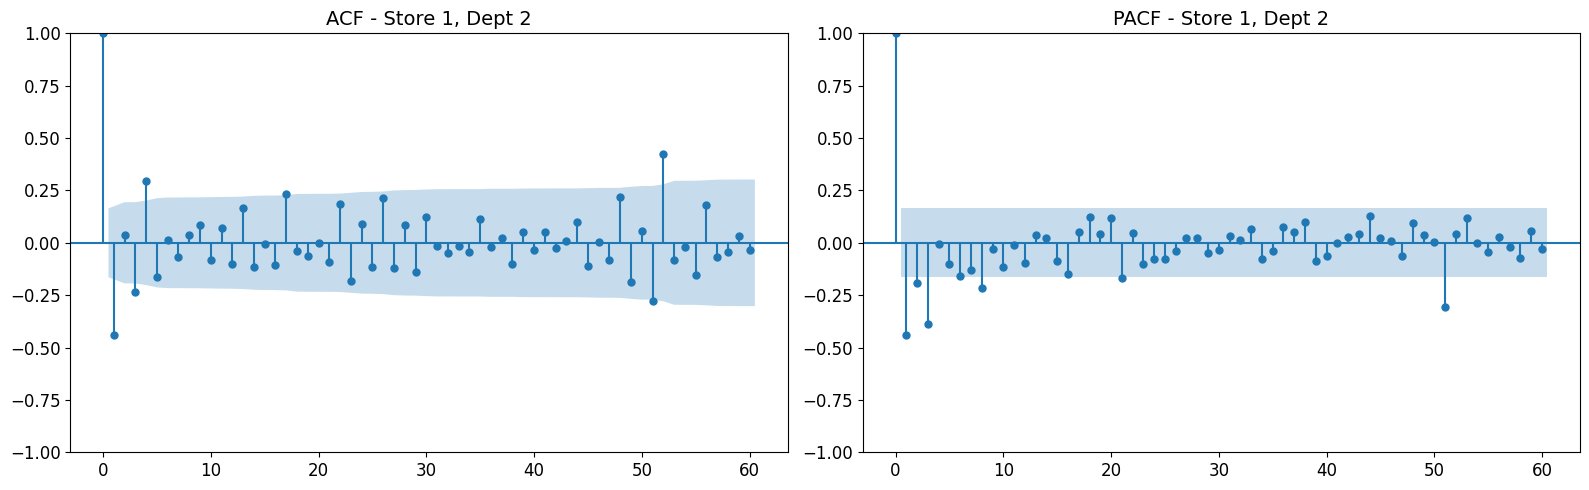

In [18]:
plot_acf_pacf(train_boxcox, store=1, dept=2)


In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.special import inv_boxcox
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Store forecasts
sarima_forecasts = {}

# Group-level sizes in original dataset (before filling! — i.e., real data coverage)
min_required_points = 120
combo_lengths = train_df.groupby(['Store', 'Dept']).size()

# List of combos to iterate over
eligible_combos = [combo for combo in train_boxcox.groupby(['Store', 'Dept']).groups
                   if combo_lengths.get(combo, 0) >= min_required_points]
limited_combos = eligible_combos[:5]

# SARIMA parameters
order = (4, 1, 4) # (p, d, q) past values to predict / make stationary / forecast errors
seasonal_order = (1, 1, 1, 52)  #(P, D, Q, s)

# Use tqdm for progress tracking
for (store, dept) in tqdm(limited_combos, desc="Training SARIMA models"):
    
    group = train_boxcox[(train_boxcox['Store'] == store) & (train_boxcox['Dept'] == dept)]
    series = group.sort_values('Date')[['Date', 'Sales_Boxcox']].fillna(0).reset_index(drop=True)
    
    if len(series) < 60:  # still need enough post-Box-Cox
        continue

    # Train-validation split: 80% train, 20% test
    split_idx = int(len(series) * 0.9)
    train_data = series.iloc[:split_idx]
    val_data = series.iloc[split_idx:]

    try:
        # Fit SARIMA model (without exog)
        model = SARIMAX(
            train_data['Sales_Boxcox'],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        model_fit = model.fit(
            maxiter=200,
            cov_type='robust', 
            full_output=True,
            method='powell',
        )

        # Forecast for validation period
        boxcox_preds = model_fit.forecast(steps=len(val_data))

        # Inverse Box-Cox
        lam = boxcox_lambdas.get((store, dept), None)
        if lam is None:
            continue  # can't inverse without lambda
        preds = inv_boxcox(boxcox_preds, lam)

        # Store for analysis/plotting
        sarima_forecasts[(store, dept)] = {
            'dates': val_data['Date'].values,
            'y_true': inv_boxcox(val_data['Sales_Boxcox'].values, lam),
            'y_pred': preds
        }

    except Exception as e:
        print(f"Skipping Store {store}, Dept {dept} due to SARIMA error: {e}")


Training SARIMA models:   0%|          | 0/5 [00:00<?, ?it/s]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Optimization terminated successfully.
         Current function value: -1.062615
         Iterations: 7
         Function evaluations: 2203


Training SARIMA models:  20%|██        | 1/5 [02:18<09:14, 138.67s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Optimization terminated successfully.
         Current function value: -1.409252
         Iterations: 5
         Function evaluations: 1816


Training SARIMA models:  40%|████      | 2/5 [04:09<06:06, 122.02s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



...

Training SARIMA models:  60%|██████    | 3/5 [07:16<05:03, 151.87s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Optimization terminated successfully.
         Current function value: -1.548171
         Iterations: 5
         Function evaluations: 2151


Training SARIMA models:  80%|████████  | 4/5 [09:49<02:32, 152.29s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Optimization terminated successfully.
         Current function value: -0.652565
         Iterations: 8
         Function evaluations: 1313


Training SARIMA models: 100%|██████████| 5/5 [11:22<00:00, 136.41s/it]


In [20]:
group = train_boxcox[(train_boxcox['Store'] == 1) & (train_boxcox['Dept'] == 1)]
# series = group.sort_values('Date')[['Date', 'Sales_Boxcox']].fillna(0).reset_index(drop=True)
series = group.sort_values('Date')[['Date', 'Sales_Boxcox']].dropna().reset_index(drop=True)
print(group[['Date', 'Weekly_Sales']].head(10))
print(group[['Date', 'Sales_Boxcox']].head(10))

display(series)

        Date  Weekly_Sales
0 2010-02-05      24.92450
1 2010-02-12      46.03949
2 2010-02-19      41.59555
3 2010-02-26      19.40354
4 2010-03-05      21.82790
5 2010-03-12      21.04339
6 2010-03-19      22.13664
7 2010-03-26      26.22921
8 2010-04-02      57.25843
9 2010-04-09      42.96091
        Date  Sales_Boxcox
0 2010-02-05      0.440356
1 2010-02-12      0.440580
2 2010-02-19      0.440561
3 2010-02-26      0.440128
4 2010-03-05      0.440251
5 2010-03-12      0.440216
6 2010-03-19      0.440264
7 2010-03-26      0.440389
8 2010-04-02      0.440609
9 2010-04-09      0.440568


,Date,Sales_Boxcox
0,2010-02-05,0.440356
1,2010-02-12,0.440580
2,2010-02-19,0.440561
3,2010-02-26,0.440128
4,2010-03-05,0.440251
...,...,...
138,2012-09-28,0.440099
139,2012-10-05,0.440254
140,2012-10-12,0.440288
141,2012-10-19,0.440335


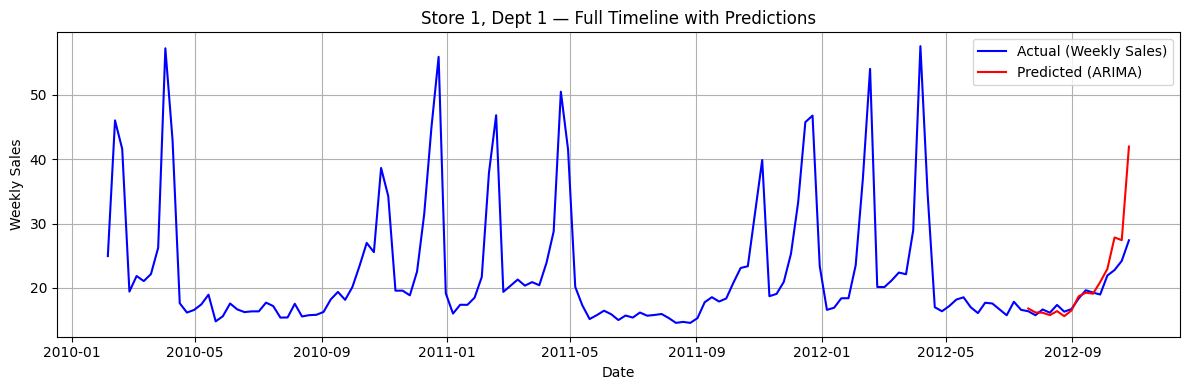

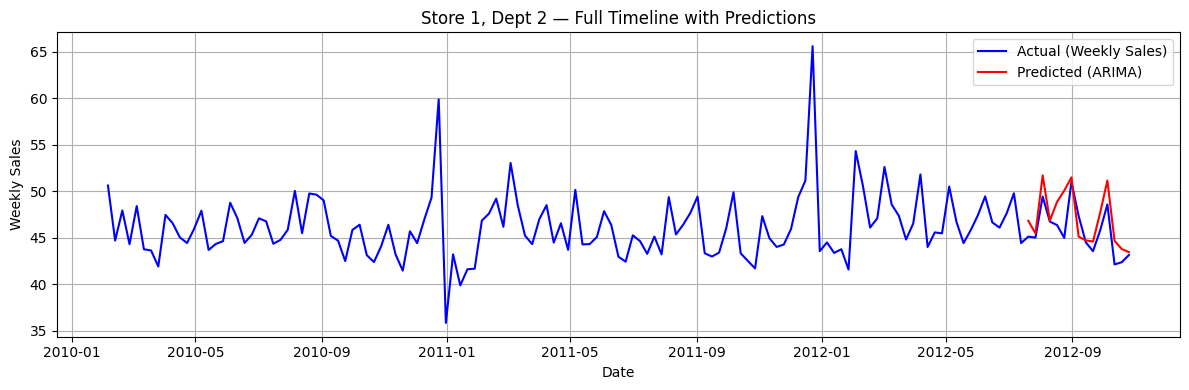

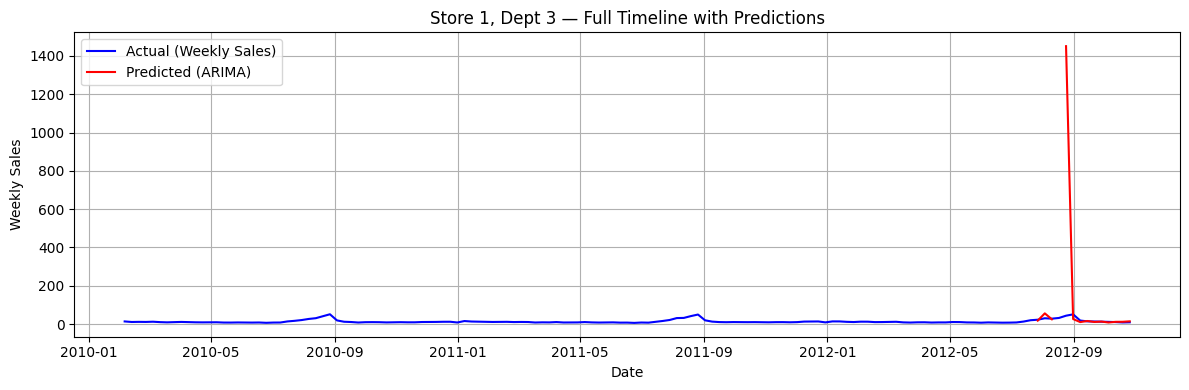

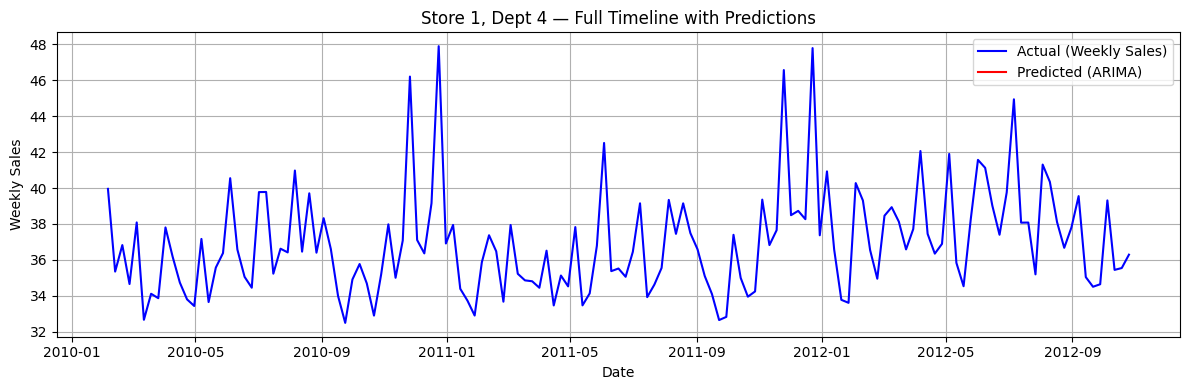

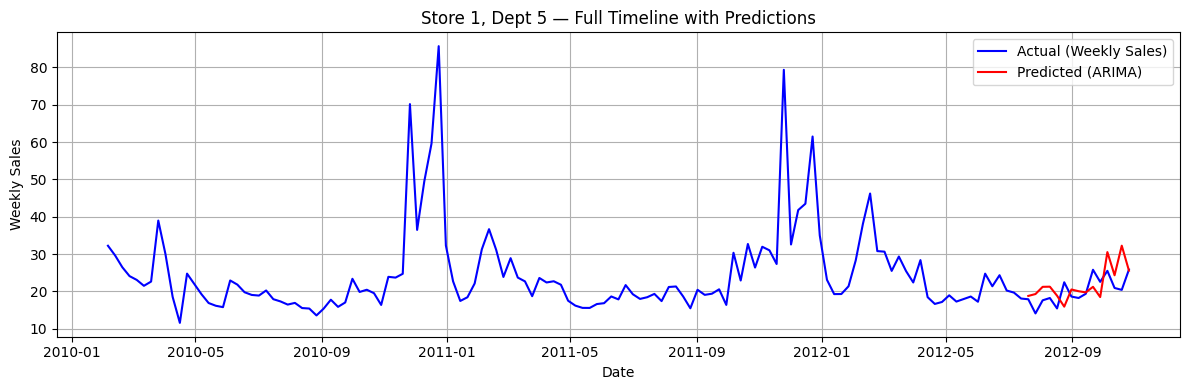

In [27]:
for (store, dept), result in sarima_forecasts.items():
    # Retrieve the full original series
    full_series = train_boxcox[
        (train_boxcox['Store'] == store) & (train_boxcox['Dept'] == dept)
    ].sort_values('Date')

    # Recover inverse Box-Cox of full sales
    lam = boxcox_lambdas.get((store, dept), None)
    if lam is None:
        continue
    
    full_sales = inv_boxcox(full_series['Sales_Boxcox'].dropna(), lam)
    full_dates = full_series['Date'].dropna()

    # Determine where prediction starts (validation start index)
    val_start_date = result['dates'][0]

    # Plot full actual series
    plt.figure(figsize=(12, 4))
    plt.plot(full_dates, full_sales, label='Actual (Weekly Sales)', color='blue')

    # Plot predicted values starting from validation start
    plt.plot(result['dates'], result['y_pred'], label='Predicted (ARIMA)', color='red')

    # Visual polish
    plt.title(f"Store {store}, Dept {dept} — Full Timeline with Predictions")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_forecast_combo(store: int, dept: int):
    result = arima_forecasts.get((store, dept))
    if not result:
        print(f"No forecast for Store {store}, Dept {dept}")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(result['dates'], result['y_true'], label='Actual', color='blue')
    plt.plot(result['dates'], result['y_pred'], label='Predicted', color='red')
    plt.title(f'Store {store}, Dept {dept} – Forecast vs Actual')
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_forecast_combo(1, 1)
plot_forecast_combo(2, 5)
plot_forecast_combo(20, 7)


### normalisation

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Store forecasts
sarima_forecasts = {}

# Group-level sizes in original dataset (before filling)
min_required_points = 120
combo_lengths = train_df.groupby(['Store', 'Dept']).size()

# List of combos to iterate over
eligible_combos = [combo for combo in train_df_filled.groupby(['Store', 'Dept']).groups
                   if combo_lengths.get(combo, 0) >= min_required_points]
limited_combos = eligible_combos[:5]

# SARIMA parameters
order = (4, 1, 4)
seasonal_order = (1, 1, 1, 52)

# Progress bar
for (store, dept) in tqdm(limited_combos, desc="Training SARIMA models (Z-score normalized)"):
    group = train_df_filled[(train_df_filled['Store'] == store) & (train_df_filled['Dept'] == dept)]
    series = group.sort_values('Date')[['Date', 'Weekly_Sales']].copy()

    if len(series) < 60:
        continue

    # Standardize (mean 0, std 1)
    mean = series['Weekly_Sales'].mean()
    std = series['Weekly_Sales'].std()
    if std == 0 or np.isnan(std):
        continue
    series['Sales_Standardized'] = (series['Weekly_Sales'] - mean) / std

    # Train-validation split
    split_idx = int(len(series) * 0.9)
    train_data = series.iloc[:split_idx]
    val_data = series.iloc[split_idx:]

    try:
        model = SARIMAX(
            train_data['Sales_Standardized'],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        model_fit = model.fit(
            maxiter=200,
            cov_type='robust',
            full_output=True,
            method='powell',
        )

        # Forecast
        preds_std = model_fit.forecast(steps=len(val_data))

        # Inverse transform
        preds = preds_std * std + mean
        y_true = val_data['Weekly_Sales'].values

        # Store results
        sarima_forecasts[(store, dept)] = {
            'dates': val_data['Date'].values,
            'y_true': y_true,
            'y_pred': preds
        }

    except Exception as e:
        print(f"Skipping Store {store}, Dept {dept} due to SARIMA error: {e}")


Training SARIMA models (Z-score normalized):   0%|          | 0/5 [00:00<?, ?it/s]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Optimization terminated successfully.
         Current function value: 0.110346
         Iterations: 22
         Function evaluations: 2745


Training SARIMA models (Z-score normalized):  20%|██        | 1/5 [03:00<12:01, 180.27s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



Optimization terminated successfully.
         Current function value: 0.057265
         Iterations: 34
         Function evaluations: 4713


C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

Training SARIMA models (Z-score normalized):  40%|████      | 2/5 [08:07<12:44, 254.77s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\s

...

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

Training SARIMA models (Z-score normalized):  60%|██████    | 3/5 [10:04<06:23, 191.84s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\s

Optimization terminated successfully.
         Current function value: 0.097809
         Iterations: 21
         Function evaluations: 2889


C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

Training SARIMA models (Z-score normalized):  80%|████████  | 4/5 [13:27<03:16, 196.21s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\s

Optimization terminated successfully.
         Current function value: -0.010461
         Iterations: 88
         Function evaluations: 10913


C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

Training SARIMA models (Z-score normalized): 100%|██████████| 5/5 [25:59<00:00, 311.95s/it]


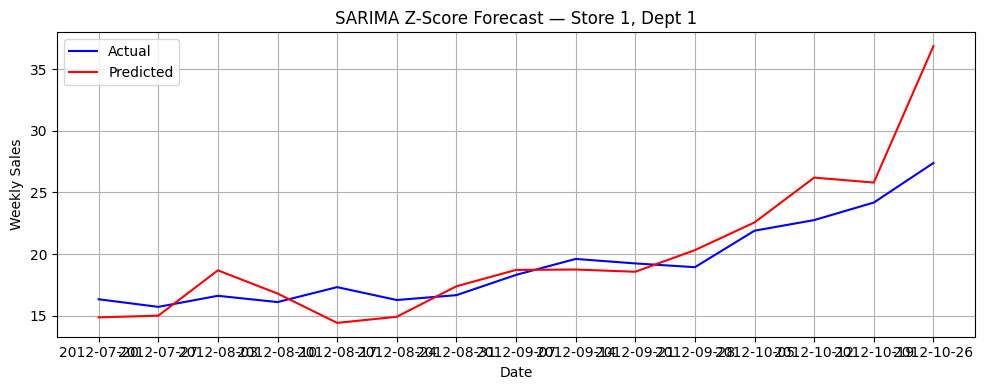

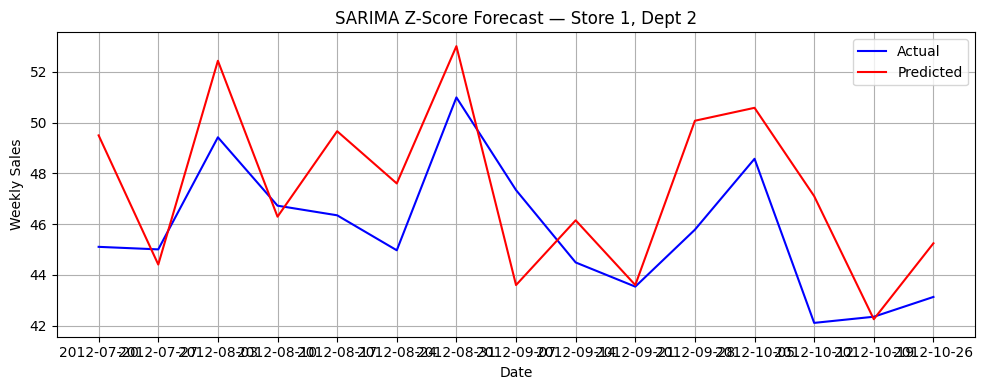

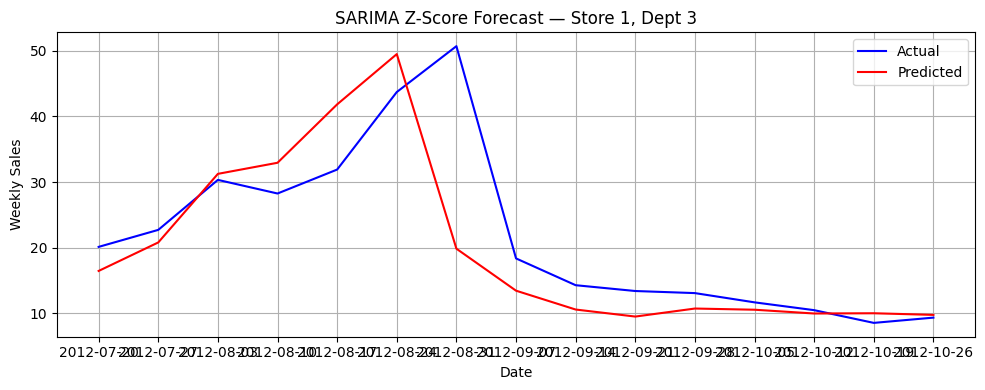

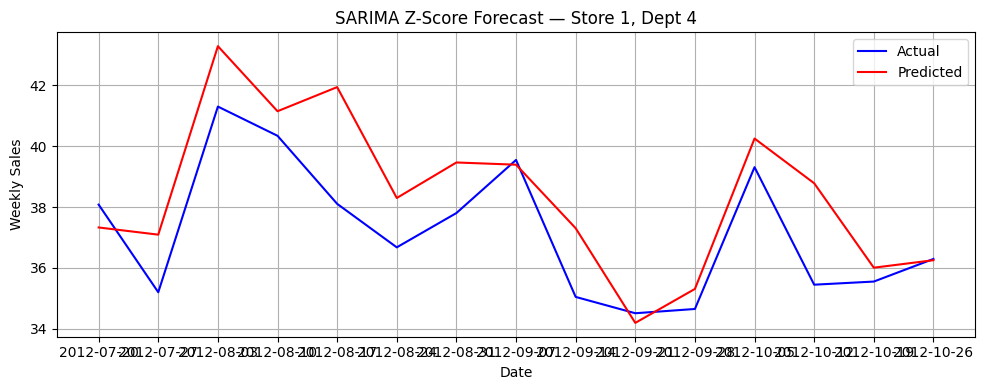

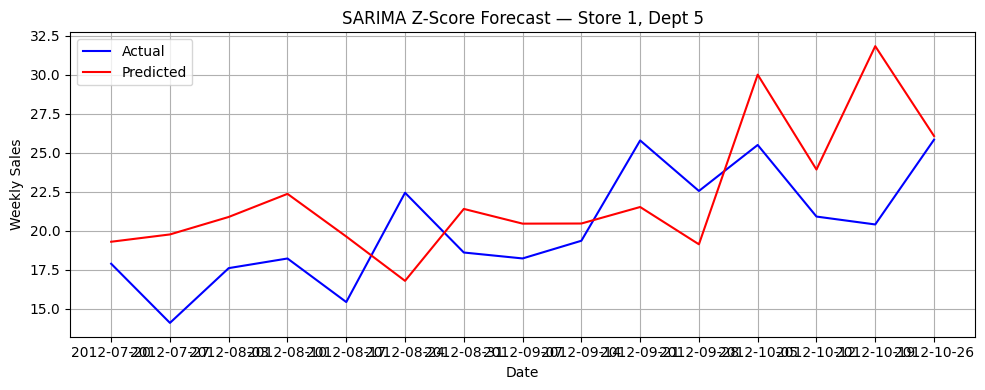

In [29]:
for (store, dept), result in sarima_forecasts.items():
    plt.figure(figsize=(10, 4))
    plt.plot(result['dates'], result['y_true'], label='Actual', color='blue')
    plt.plot(result['dates'], result['y_pred'], label='Predicted', color='red')
    plt.title(f'SARIMA Z-Score Forecast — Store {store}, Dept {dept}')
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### aggregated model

In [30]:
# Make sure Date is datetime
train_df_filled['Date'] = pd.to_datetime(train_df_filled['Date'])

# Aggregate per Dept (sum over stores)
dept_series = train_df_filled.groupby(['Dept', 'Date'])['Weekly_Sales'].sum().reset_index()

# Aggregate per Store (sum over depts)
store_series = train_df_filled.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()


In [31]:
dept_series.head(4)

,Dept,Date,Weekly_Sales
0,1,2010-02-05,881.83341
1,1,2010-02-12,1457.18240
2,1,2010-02-19,1118.25736
3,1,2010-02-26,681.39158


In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm

sarima_store_models = {}
sarima_dept_models = {}
store_contributions = {}
dept_contributions = {}

order = (4, 1, 4)
seasonal_order = (1, 1, 1, 52)

# === Dept-Level Models ===
total_dept_sales = dept_series.groupby('Dept')['Weekly_Sales'].sum().sum()

for dept, group in tqdm(dept_series.groupby('Dept'), desc="Training per Dept"):
    group = group.sort_values('Date')
    series = group.set_index('Date')['Weekly_Sales']

    if len(series) < 60:
        continue

    # Compute contribution of this dept
    dept_total = series.sum()
    dept_contributions[dept] = dept_total / total_dept_sales

    # Train/val split
    split_idx = int(len(series) * 0.9)
    train_series = series.iloc[:split_idx]
    val_series = series.iloc[split_idx:]

    try:
        model = SARIMAX(train_series,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fit = model.fit(maxiter=200, method='powell', disp=False)
        sarima_dept_models[dept] = {
            'model': fit,
            'train_series': train_series,
            'val_series': val_series
        }
    except Exception as e:
        print(f"Dept {dept} failed: {e}")

# === Store-Level Models ===
total_store_sales = store_series.groupby('Store')['Weekly_Sales'].sum().sum()

for store, group in tqdm(store_series.groupby('Store'), desc="Training per Store"):
    group = group.sort_values('Date')
    series = group.set_index('Date')['Weekly_Sales']

    if len(series) < 60:
        continue

    # Compute contribution of this store
    store_total = series.sum()
    store_contributions[store] = store_total / total_store_sales

    # Train/val split
    split_idx = int(len(series) * 0.9)
    train_series = series.iloc[:split_idx]
    val_series = series.iloc[split_idx:]

    try:
        model = SARIMAX(train_series,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fit = model.fit(maxiter=200, method='powell', disp=False)
        sarima_store_models[store] = {
            'model': fit,
            'train_series': train_series,
            'val_series': val_series
        }
    except Exception as e:
        print(f"Store {store} failed: {e}")


Training per Dept:   0%|          | 0/81 [00:00<?, ?it/s]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

Training per Dept:   1%|          | 1/81 [01:57<2:36:01, 117.01s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information 

In [71]:
import matplotlib.pyplot as plt

def plot_sarima_result(model_dict, key, title='SARIMA Forecast'):
    """
    Plots SARIMA model forecast vs actuals for a specific store or department.

    Args:
        model_dict (dict): Dictionary containing trained SARIMA models with data.
        key (int): Store or Dept key to access the correct entry.
        title (str): Title of the plot.
    """
    if key not in model_dict:
        print(f"Key {key} not found in model dictionary.")
        return

    model_data = model_dict[key]
    model_fit = model_data['model']
    train_series = model_data['train_series']
    val_series = model_data['val_series']

    # Generate forecast for the validation range
    forecast = model_fit.forecast(steps=len(val_series))

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(train_series.index, train_series.values, label='Train', color='blue')
    plt.plot(val_series.index, val_series.values, label='Validation', color='green')
    plt.plot(val_series.index, forecast, label='Forecast', color='red', linestyle='--')

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


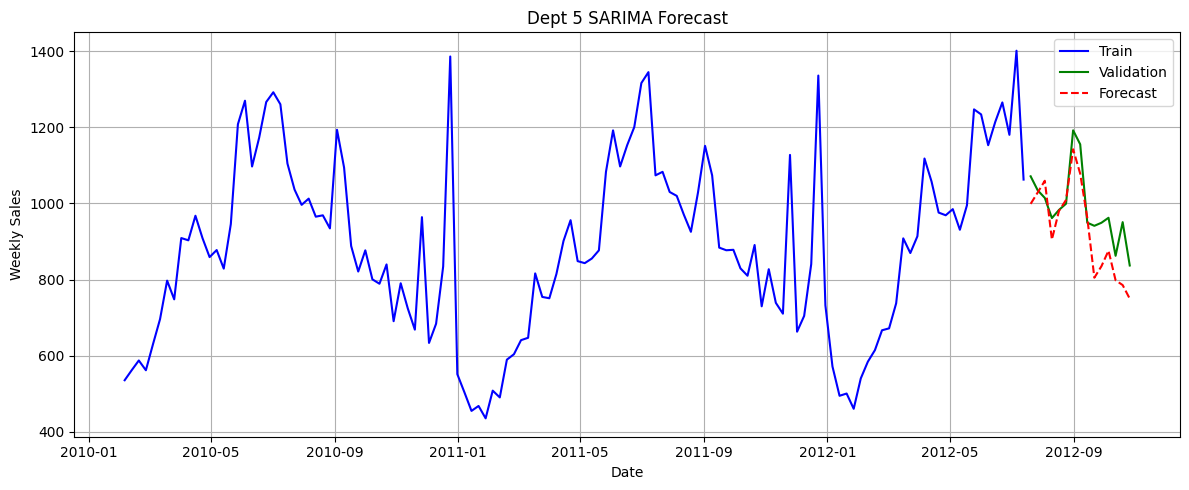

In [72]:
plot_sarima_result(sarima_dept_models, key=9, title='Dept 5 SARIMA Forecast')


In [74]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def find_best_blend_with_contrib(store: int, dept: int):
    if store not in sarima_store_models or dept not in sarima_dept_models:
        print(f"Store {store} or Dept {dept} model not found.")
        return

    store_data = sarima_store_models[store]
    dept_data = sarima_dept_models[dept]
    store_model = store_data['model']
    dept_model = dept_data['model']
    store_val_len = len(store_data['val_series'])
    dept_val_len = len(dept_data['val_series'])
    val_len = min(store_val_len, dept_val_len)

    store_contrib = store_contributions.get(store, 0)
    dept_contrib = dept_contributions.get(dept, 0)

    store_forecast = store_model.forecast(steps=val_len)
    dept_forecast = dept_model.forecast(steps=val_len)

    # Actual data
    actual_series = train_df_filled[
        (train_df_filled['Store'] == store) & 
        (train_df_filled['Dept'] == dept)
    ].sort_values('Date').set_index('Date')['Weekly_Sales']

    split_idx = int(len(actual_series) * 0.9)
    val_actual = actual_series.iloc[split_idx:split_idx + val_len]

    if len(val_actual) < val_len:
        print(f"Not enough validation data for Store {store}, Dept {dept}")
        return

    best_mse = float('inf')
    best_w = None
    best_pred = None

    # Try different blend ratios of the store+dept components
    for w in range(1, 100):
        alpha = w / 100
        beta = 1 - alpha

        combined = (
            alpha * (store_forecast[:val_len] * store_contrib) +
            beta  * (dept_forecast[:val_len] * dept_contrib)
        )

        mse = mean_squared_error(val_actual.values, combined)
        if mse < best_mse:
            best_mse = mse
            best_w = w
            best_pred = combined

    # Plot
    train_actual = actual_series.iloc[:split_idx]
    val_dates = val_actual.index

    plt.figure(figsize=(12, 5))
    plt.plot(train_actual.index, train_actual, label="Train (Actual)", color="blue")
    plt.plot(val_actual.index, val_actual, label="Validation (Actual)", color="black")
    plt.plot(val_dates, best_pred, label=f"Best Prediction (store={best_w}%, dept={100-best_w}%)", color="red", linestyle="--")
    plt.title(f"Forecast for Store {store}, Dept {dept} — MSE: {best_mse:.2f}")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"✅ Best blend for Store {store}, Dept {dept}: store = {best_w}%, dept = {100 - best_w}%, MSE = {best_mse:.2f}")


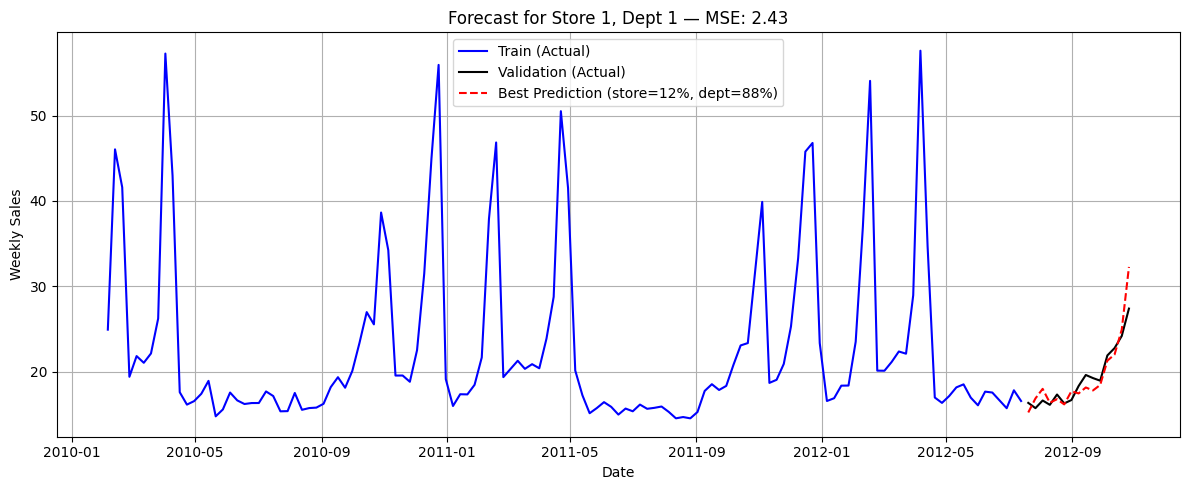

✅ Best blend for Store 1, Dept 1: store = 12%, dept = 88%, MSE = 2.43


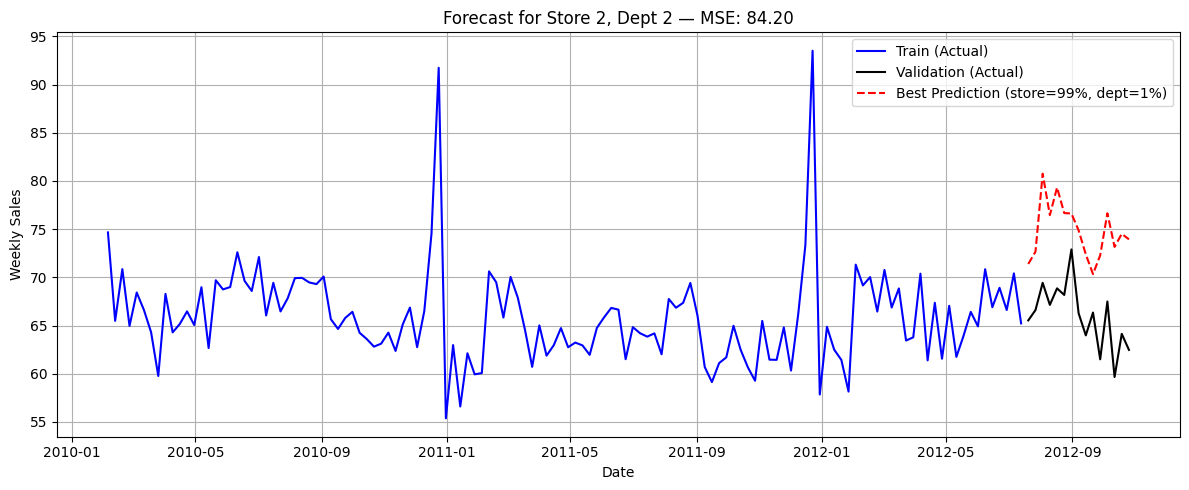

✅ Best blend for Store 2, Dept 2: store = 99%, dept = 1%, MSE = 84.20


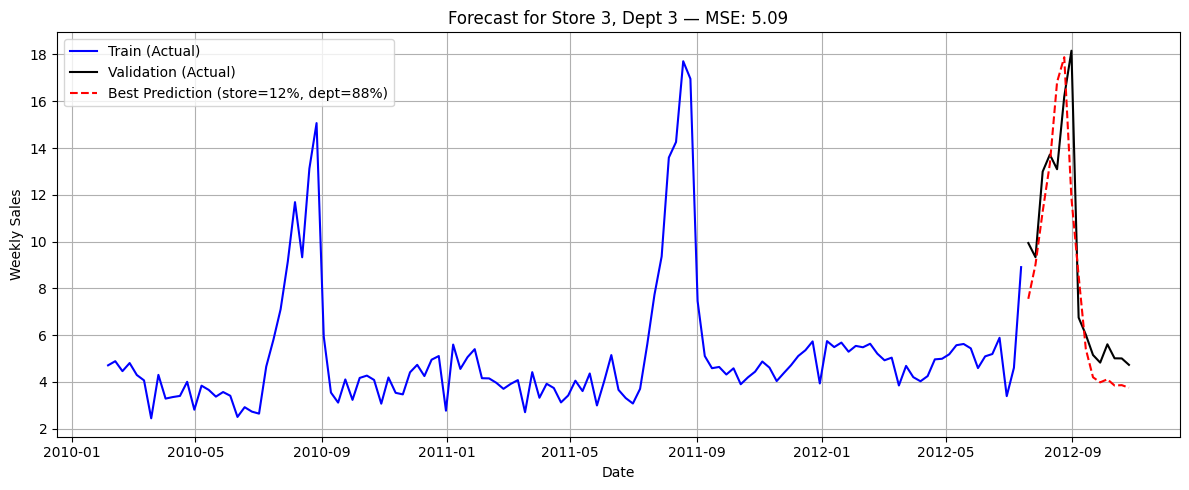

✅ Best blend for Store 3, Dept 3: store = 12%, dept = 88%, MSE = 5.09


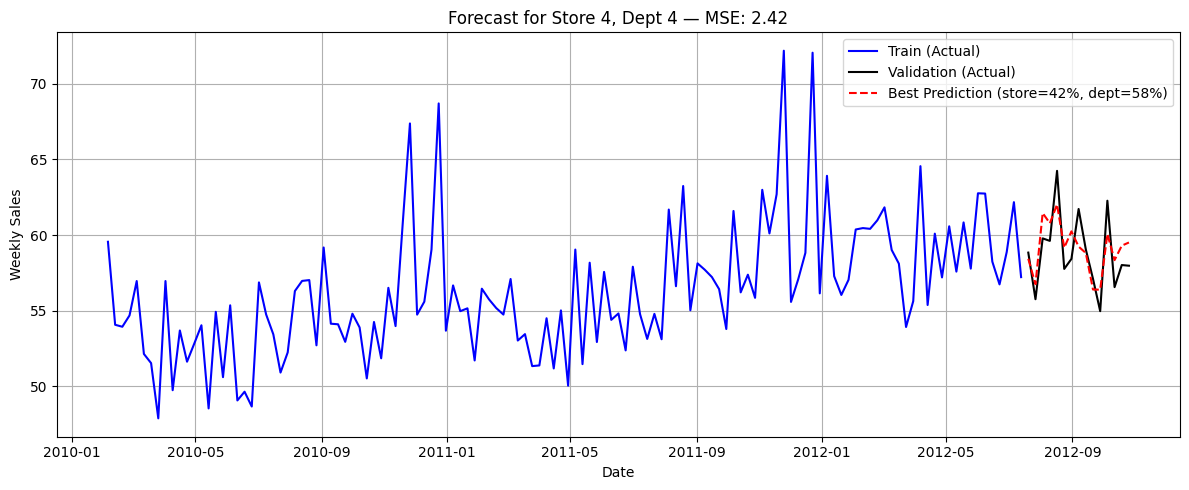

✅ Best blend for Store 4, Dept 4: store = 42%, dept = 58%, MSE = 2.42


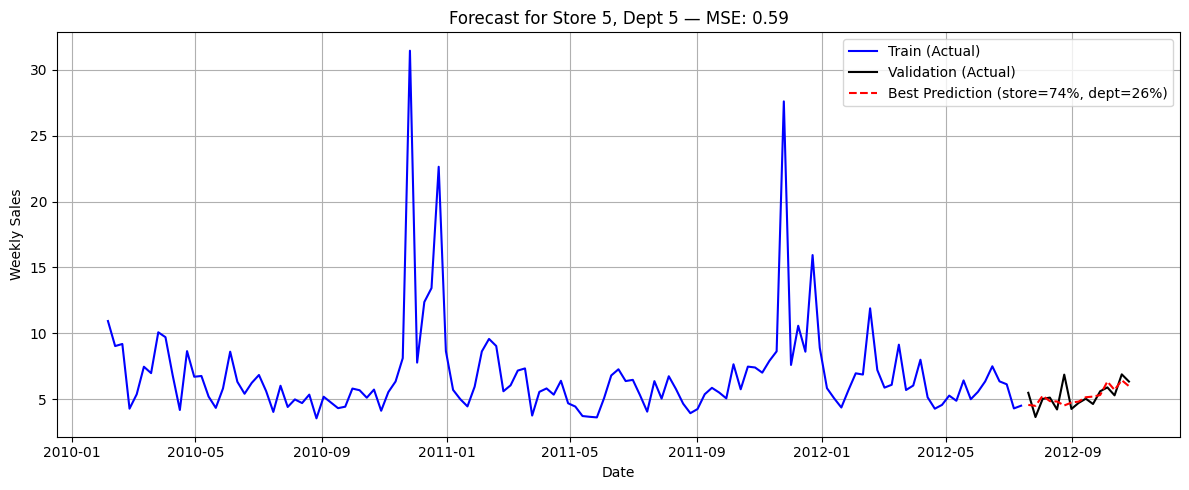

✅ Best blend for Store 5, Dept 5: store = 74%, dept = 26%, MSE = 0.59


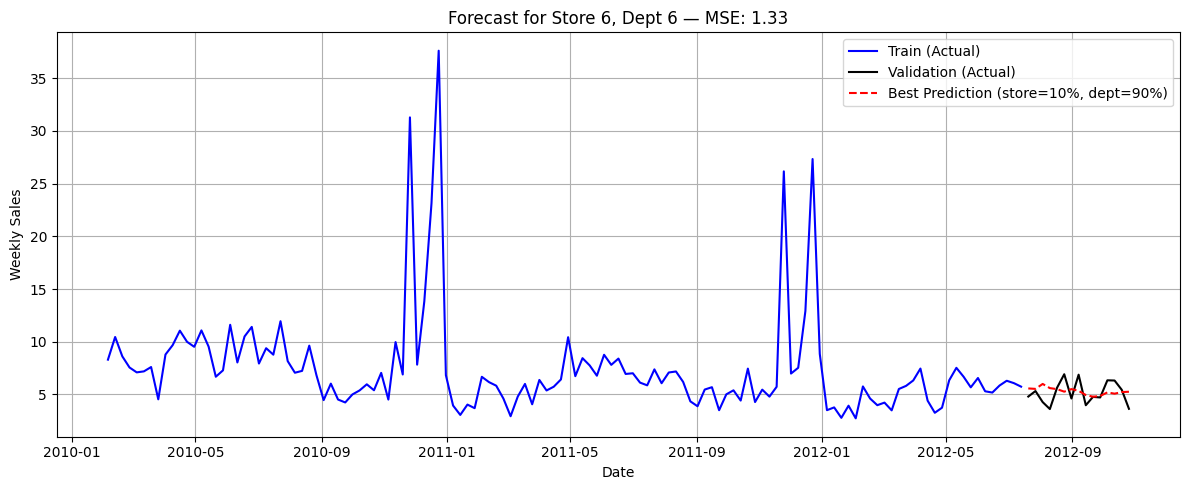

✅ Best blend for Store 6, Dept 6: store = 10%, dept = 90%, MSE = 1.33


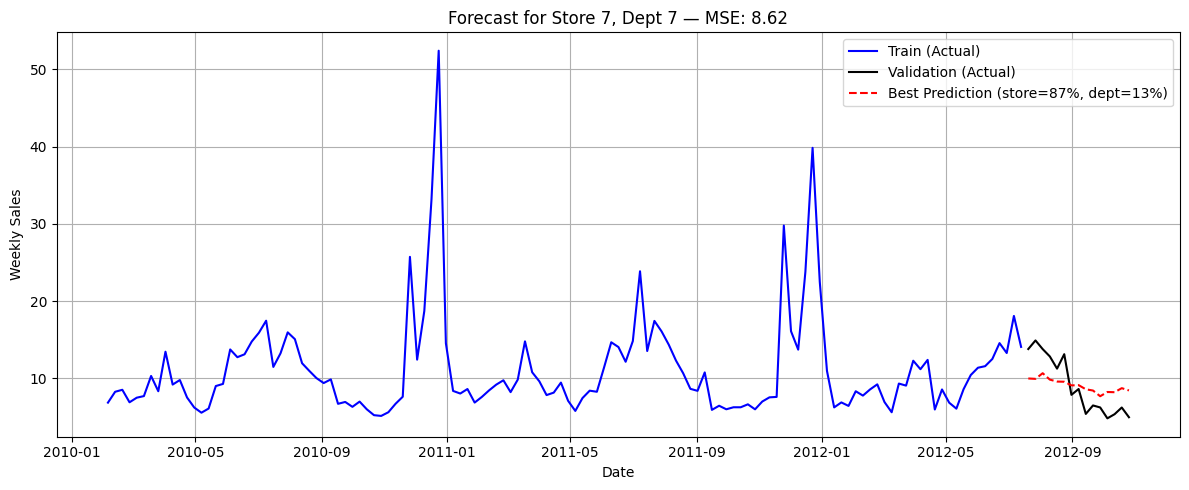

✅ Best blend for Store 7, Dept 7: store = 87%, dept = 13%, MSE = 8.62


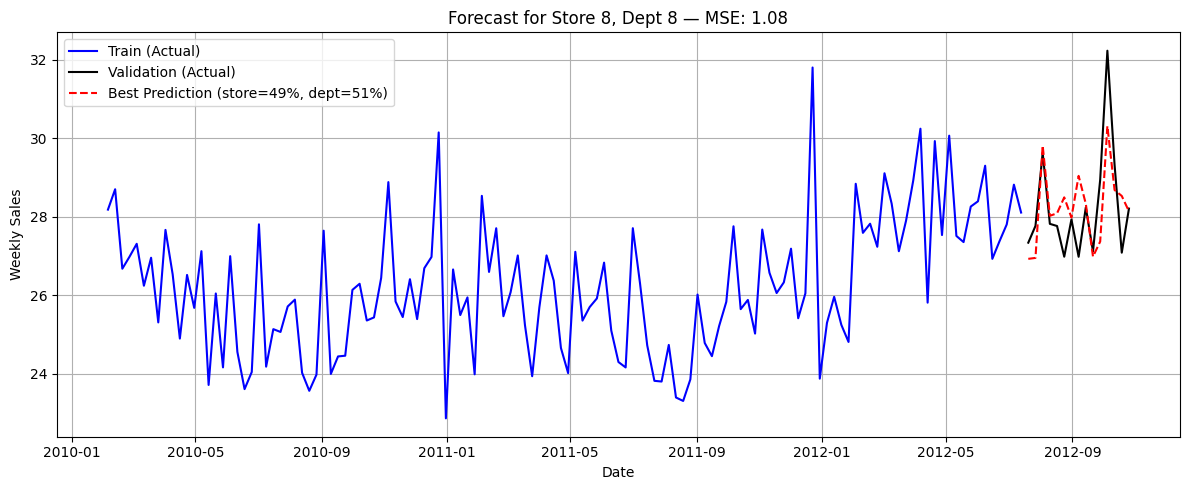

✅ Best blend for Store 8, Dept 8: store = 49%, dept = 51%, MSE = 1.08


In [75]:
for i in range(1, 9):
    find_best_blend_with_contrib(store=i, dept=i)


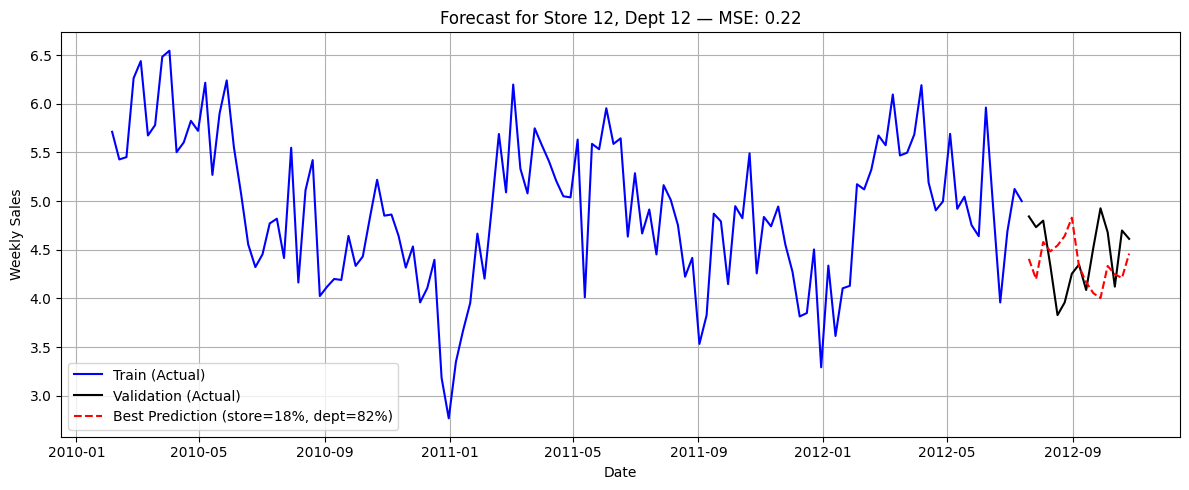

✅ Best blend for Store 12, Dept 12: store = 18%, dept = 82%, MSE = 0.22


In [82]:
find_best_blend_with_contrib(store=12, dept=12)


In [56]:
train_df_filled.head(5)

,Date,Store,Dept,Weekly_Sales
0,2010-02-05,1,1,24.92450
1,2010-02-12,1,1,46.03949
2,2010-02-19,1,1,41.59555
3,2010-02-26,1,1,19.40354
4,2010-03-05,1,1,21.82790


### predict

In [76]:
import pandas as pd
import numpy as np

def predict_test_dataset(test_df, store_weight=0.2, dept_weight=0.8):
    test_df = test_df.copy()
    test_df['Date'] = pd.to_datetime(test_df['Date'])

    predictions = []

    grouped = test_df.groupby(['Store', 'Dept'])

    for (store, dept), group in tqdm(grouped, desc="Generating Test Predictions"):
        # Ensure both models exist
        if store not in sarima_store_models or dept not in sarima_dept_models:
            print(f"Missing model for Store {store} or Dept {dept}, skipping...")
            continue

        # Get forecast horizon
        future_dates = group.sort_values('Date')['Date']
        n_steps = len(future_dates)

        # Forecast
        store_model = sarima_store_models[store]['model']
        dept_model = sarima_dept_models[dept]['model']

        store_contrib = store_contributions.get(store, 0)
        dept_contrib = dept_contributions.get(dept, 0)

        store_forecast = store_model.forecast(steps=n_steps)
        dept_forecast = dept_model.forecast(steps=n_steps)

        combined_forecast = (
            store_forecast.values * store_contrib * store_weight +
            dept_forecast.values * dept_contrib * dept_weight
        )

        # Multiply back to original scale
        combined_forecast *= 1000

        # Construct prediction IDs and save
        ids = group.apply(lambda row: f"{row['Store']}_{row['Dept']}_{row['Date'].date()}", axis=1)
        df_preds = pd.DataFrame({
            'Id': ids,
            'Weekly_Sales': combined_forecast
        })

        predictions.append(df_preds)

    # Combine all predictions
    submission_df = pd.concat(predictions, ignore_index=True)

    # Ensure correct order
    submission_df = submission_df.sort_values('Id')

    return submission_df


In [77]:
test_df = pd.read_csv("data/test.csv/test.csv")
submission = predict_test_dataset(test_df, store_weight=0.2, dept_weight=0.8)
submission.to_csv("submission2.csv", index=False)


Generating Test Predictions: 100%|██████████| 3169/3169 [03:39<00:00, 14.45it/s]


### find appropriate constant

In [84]:
from sklearn.metrics import mean_squared_error

# Dictionary to hold optimal additive offsets per (store, dept)
dept_store_offsets = {}

def find_best_offset(store: int, dept: int):
    # Make sure both models exist
    if store not in sarima_store_models or dept not in sarima_dept_models:
        return None

    store_model_data = sarima_store_models[store]
    dept_model_data = sarima_dept_models[dept]
    store_model = store_model_data['model']
    dept_model = dept_model_data['model']
    store_val_len = len(store_model_data['val_series'])
    dept_val_len = len(dept_model_data['val_series'])

    # Forecasts
    store_forecast = store_model.forecast(steps=store_val_len)
    dept_forecast = dept_model.forecast(steps=dept_val_len)
    val_len = min(len(store_forecast), len(dept_forecast))

    # Actual values
    actual_series = train_df_filled[
        (train_df_filled['Store'] == store) & 
        (train_df_filled['Dept'] == dept)
    ].sort_values('Date')
    actual_series = actual_series.set_index('Date')['Weekly_Sales']
    split_idx = int(len(actual_series) * 0.9)
    val_actual = actual_series.iloc[split_idx:split_idx + val_len].values

    # Fixed 20% store contribution
    store_weight = 0.2
    base_pred = store_forecast[:val_len].values * store_weight

    best_offset = 0
    best_mse = float('inf')

    for offset in np.linspace(0.01, 2, 101):  # try 201 values between -5000 and +5000
        pred = (base_pred + dept_forecast[:val_len].values * 0.8 ) * offset
        mse = mean_squared_error(val_actual, pred * 1000)  # rescale for comparison
        if mse < best_mse:
            best_mse = mse
            best_offset = offset

    return best_offset

# Learn all offsets
for (store, dept) in tqdm(train_df_filled.groupby(['Store', 'Dept']).groups.keys(), desc="Tuning offsets"):
    offset = find_best_offset(store, dept)
    if offset is not None:
        dept_store_offsets[(store, dept)] = offset


Tuning offsets: 100%|██████████| 3331/3331 [03:53<00:00, 14.25it/s]


In [ ]:
test_df = pd.read_csv("data/test.csv/test.csv")
submission = predict_test_dataset(test_df, store_weight=0.2, dept_weight=0.8)
submission.to_csv("submission3.csv", index=False)


In [78]:
len(submission)

115064

In [86]:
import pandas as pd
import numpy as np
from tqdm import tqdm

def predict_test_dataset_with_offsets(
    test_df: pd.DataFrame,
    store_weight: float = 0.2,
    dept_weight: float = 0.8,
    scale: float = 1000.0
) -> pd.DataFrame:
    """
    Generate predictions on test dataset using SARIMA store/dept models with offset correction.

    Parameters:
    - test_df: DataFrame with ['Store', 'Dept', 'Date']
    - store_weight: float, weight for store model
    - dept_weight: float, weight for department model
    - scale: float, multiply prediction by this (e.g., 1000 to undo earlier division)

    Returns:
    - submission_df: DataFrame with columns ['Id', 'Weekly_Sales']
    """

    test_df = test_df.copy()
    test_df['Date'] = pd.to_datetime(test_df['Date'])

    predictions = []

    grouped = test_df.groupby(['Store', 'Dept'])

    for (store, dept), group in tqdm(grouped, desc="Generating Test Predictions"):
        # Skip if models not available
        if store not in sarima_store_models or dept not in sarima_dept_models:
            print(f"Missing model for Store {store} or Dept {dept}, skipping...")
            continue

        # Get forecast horizon
        future_dates = group.sort_values('Date')['Date']
        n_steps = len(future_dates)

        # Forecast
        store_model = sarima_store_models[store]['model']
        dept_model = sarima_dept_models[dept]['model']

        store_contrib = store_contributions.get(store, 0)
        dept_contrib = dept_contributions.get(dept, 0)

        store_forecast = store_model.forecast(steps=n_steps)
        dept_forecast = dept_model.forecast(steps=n_steps)

        # Weighted average
        combined_forecast = (
            store_forecast.values * store_contrib * store_weight +
            dept_forecast.values * dept_contrib * dept_weight
        )

        # Apply offset if available
        offset = dept_store_offsets.get((store, dept), 0)
        combined_forecast *= offset

        # Restore to original scale
        combined_forecast *= scale

        # Generate IDs
        ids = group.apply(lambda row: f"{row['Store']}_{row['Dept']}_{row['Date'].date()}", axis=1)
        df_preds = pd.DataFrame({
            'Id': ids,
            'Weekly_Sales': combined_forecast
        })

        predictions.append(df_preds)

    # Combine all predictions
    submission_df = pd.concat(predictions, ignore_index=True)
    submission_df = submission_df.sort_values('Id')

    return submission_df


In [ ]:
predictions_df = predict_test_dataset_with_offsets(test_df=test_df)

In [88]:
def concatenate_predictions_with_actuals(predictions_df: pd.DataFrame, train_df: pd.DataFrame) -> pd.DataFrame:
    """
    Combine predictions with actuals from train_df_filled for side-by-side comparison.

    Parameters:
    - predictions_df: DataFrame with columns ['Id', 'Weekly_Sales'] from test predictions
    - train_df: Full training data DataFrame (e.g., train_df_filled) containing ['Store', 'Dept', 'Date', 'Weekly_Sales']

    Returns:
    - combined_df: DataFrame with columns ['Store', 'Dept', 'Date', 'Actual_Sales', 'Predicted_Sales']
    """

    # === Process predictions ===
    pred_df = predictions_df.copy()

    # Extract Store, Dept, Date from prediction ID
    pred_df[['Store', 'Dept', 'Date']] = pred_df['Id'].str.extract(r'(\d+)_(\d+)_(\d{4}-\d{2}-\d{2})')
    pred_df['Store'] = pred_df['Store'].astype(int)
    pred_df['Dept'] = pred_df['Dept'].astype(int)
    pred_df['Date'] = pd.to_datetime(pred_df['Date'])

    pred_df = pred_df.rename(columns={'Weekly_Sales': 'Predicted_Sales'})

    # === Process actuals ===
    actual_df = train_df.copy()
    actual_df['Date'] = pd.to_datetime(actual_df['Date'])
    actual_df['Actual_Sales'] = actual_df['Weekly_Sales'] * 1000  # restore scaling
    actual_df = actual_df[['Store', 'Dept', 'Date', 'Actual_Sales']]

    # === Concatenate ===
    combined_df = pd.merge(pred_df[['Store', 'Dept', 'Date', 'Predicted_Sales']],
                           actual_df,
                           on=['Store', 'Dept', 'Date'],
                           how='outer')  # outer to show all test predictions, even if no actual

    # Optional: sort for readability
    combined_df = combined_df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)

    return combined_df


In [89]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(combined_df: pd.DataFrame, store: int, dept: int):
    """
    Plot actual vs predicted sales for a specific Store and Dept.

    Parameters:
    - combined_df: DataFrame with columns ['Store', 'Dept', 'Date', 'Actual_Sales', 'Predicted_Sales']
    - store: Store number to plot
    - dept: Dept number to plot
    """
    df = combined_df[(combined_df['Store'] == store) & (combined_df['Dept'] == dept)].sort_values('Date')

    if df.empty:
        print(f"No data found for Store {store}, Dept {dept}")
        return

    plt.figure(figsize=(12, 5))
    plt.plot(df['Date'], df['Actual_Sales'], label="Actual Sales", color="black")
    plt.plot(df['Date'], df['Predicted_Sales'], label="Predicted Sales", color="red", linestyle="--")
    plt.title(f"Store {store}, Dept {dept} – Actual vs Predicted Sales")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [90]:
submission = predict_test_dataset_with_offsets(test_df)
comparison_df = concatenate_predictions_with_actuals(submission, train_df_filled)

Generating Test Predictions: 100%|██████████| 3169/3169 [03:43<00:00, 14.17it/s]


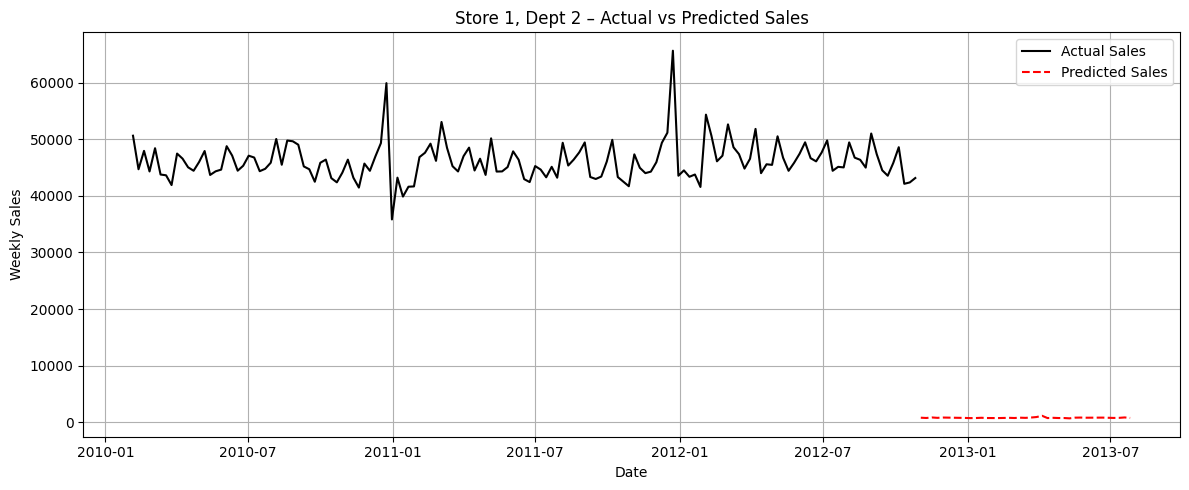

In [92]:

plot_actual_vs_predicted(comparison_df, store=1, dept=2)


### store the models locally

In [85]:
import joblib
import os

# Create a directory if it doesn't exist
os.makedirs("saved_models3", exist_ok=True)

# Save dept models
for dept, model_data in sarima_dept_models.items():
    joblib.dump(model_data, f"saved_models3/dept_model_{dept}.pkl")

# Save store models
for store, model_data in sarima_store_models.items():
    joblib.dump(model_data, f"saved_models3/store_model_{store}.pkl")

# Save contribution dictionaries
joblib.dump(dept_contributions, "saved_models3/dept_contributions.pkl")
joblib.dump(store_contributions, "saved_models3/store_contributions.pkl")


FileNotFoundError: [Errno 2] No such file or directory: 'saved_models3/dept_model_1.pkl'

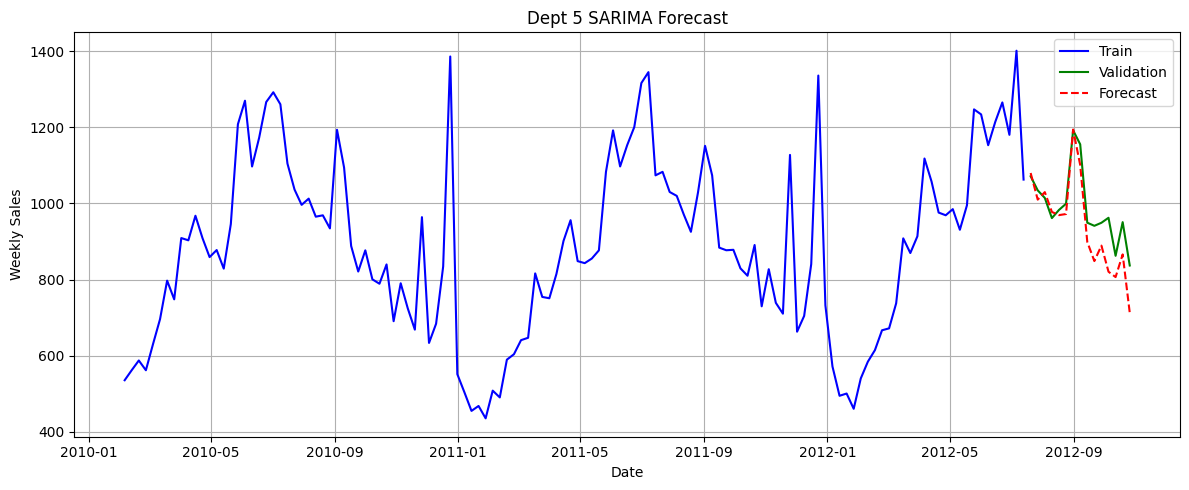

In [51]:
import glob

# Load all dept models
sarima_dept_models = {}
for path in glob.glob("saved_models/dept_model_*.pkl"):
    dept = int(path.split("_")[-1].split(".")[0])
    sarima_dept_models[dept] = joblib.load(path)

# Load all store models
sarima_store_models = {}
for path in glob.glob("saved_models/store_model_*.pkl"):
    store = int(path.split("_")[-1].split(".")[0])
    sarima_store_models[store] = joblib.load(path)

# Load contribution dictionaries
dept_contributions = joblib.load("saved_models/dept_contributions.pkl")
store_contributions = joblib.load("saved_models/store_contributions.pkl")
